# Encoding methods


## Ames Lowa Housing Dataset 
**GLADYS OUMA**

This model uses the **Housing dataset**  to predict house prices by analyzing and finding relationships between features and finding how they correlate with the target variable.
I cleaned the dataset by removing outliers, fixing MSSubClass's incorrect data type, and separating structural "no feature" values from genuinely missing data and then match each categorical variable to the right encoding technique (ordinal for ranked quality columns, one-hot for the rest) before training and validating a model.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.feature_extraction import FeatureHasher

In [29]:
df_train = pd.read_csv("train.csv")
df_train.head(5)
#df_train.info()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [30]:
df_train = df_train[~((df_train["GrLivArea"] > 4000) & (df_train["SalePrice"] < 300000))].reset_index(drop=True)


## MSSubClass

It identifies the type of dwelling involved in the sale but in the raw dataset it's stored as an integer. These numbers are just category codes and are not a measurable quantity and there's no meaningful order between dwelling types.

To fix this, the column was cast to a string type before encoding:
```python
df_train["MSSubClass"] = df_train["MSSubClass"].astype(str)
```

This ensures it's correctly picked up as a nominal categorical variable and one-hot encoded like the rest of the dwelling-type information, rather than being misread as a continuous numeric feature.

In [31]:
df_train["MSSubClass"] = df_train["MSSubClass"].astype(str)

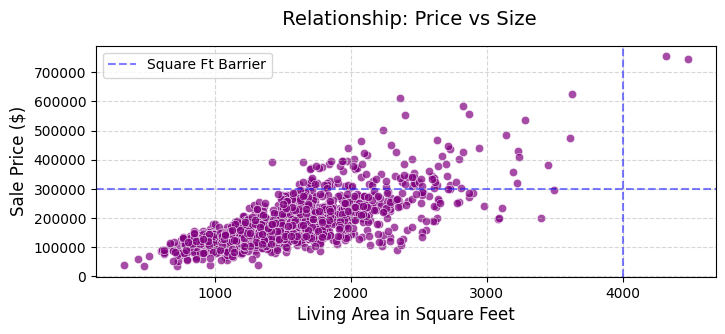

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 3))
sns.scatterplot(data=df_train, x='GrLivArea', y='SalePrice', color='purple', alpha=0.7)

plt.axvline(x=4000, color='blue', linestyle='--', alpha=0.5, label='Square Ft Barrier')
plt.axhline(y=300000, color='blue', linestyle='--', alpha=0.5)

plt.title(' Relationship: Price vs Size', fontsize=14, pad=15)
plt.xlabel('Living Area in Square Feet', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Outliers

Before encoding I got to understand why a value is missing, because in this dataset, not all missing values mean the same thing.

Pandas reads a blank cell as `NaN` (Not a Number) regardless of what that blank actually represents. If you treat every `NaN` the same way as missing value where we drop the rows or fill everything with zero or the column mean, you lose real information and can introduce misleading patterns into the model.

1. **"NA means no feature" (structural absence).**
   For several columns, `NaN` is not a data problem, it's ta way of saying the house simply      doesn't have that feature at all.
   So if a feature doesn't exist" I deliberately fill it with`"None"`, turning it into its own  category rather than erasing it.

2. **Genuinely missing / unknown data.**
   A smaller number of columns are missing for ordinary data-quality reasons meaning the value may exist in reality but wasn't recorded:
  

In [33]:

none_feature = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
for col in none_feature:
    df_train[col] = df_train[col].fillna("None")

df_train["GarageYrBlt"] = df_train["GarageYrBlt"].fillna(0)


df_train["LotFrontage"] = df_train["LotFrontage"].fillna(df_train["LotFrontage"].median())
df_train["MasVnrArea"] = df_train["MasVnrArea"].fillna(0)
df_train["Electrical"] = df_train["Electrical"].fillna(df_train["Electrical"].mode()[0])

remaining_na = df_train.isna().sum()
remaining_na[remaining_na > 0]

Series([], dtype: int64)

## Ordinal

Several columns are quality ratings with a clear order. One-hot encoding would throw that ordering away and treat Excellent and Poor as equally different from Average. These are mapped explicitly to integers instead, so the model can learn that quality increases along a scale.

In [34]:
quality_order = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

ordinal_quality_cols = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
]

for col in ordinal_quality_cols:
    df_train[col] = df_train[col].map(quality_order)

df_train[ordinal_quality_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,PoolQC
0,4,3,4,3,5,4,0,3,3,0
1,3,3,4,3,5,3,3,3,3,0
2,4,3,4,3,5,4,3,3,3,0
3,3,3,3,4,4,4,4,3,3,0
4,4,3,4,3,5,4,3,3,3,0


## One-Hot Encoding

Everything left without inherent order has no natural ranking, so one-hot encoding is the right fit because it creates a binary indicator column per category without implying any order between them.



In [35]:
X = df_train.drop(columns=["SalePrice"])
Y = df_train["SalePrice"]

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.fillna(0)

X_encoded.shape

(1458, 242)

## Training

An 80/20 train-test split with LinearRegression, run on the feature matrix built from the Ordinal + One-Hot encoding above. train_model is defined once here and reused for every encoding comparison later, so all results are trained the same way.


In [36]:

def train_model(X_data, Y_data):
    X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, Y_train)

    predictions = model.predict(X_test)
    mae = mean_absolute_error(Y_test, predictions)
    r2 = r2_score(Y_test, predictions)

    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")
    return model, X_test, Y_test, predictions

model_final, X_test_final, Y_test_final, preds_final = train_model(X_encoded, Y)

Mean Absolute Error: 20376.28
R2 Score: 0.8516


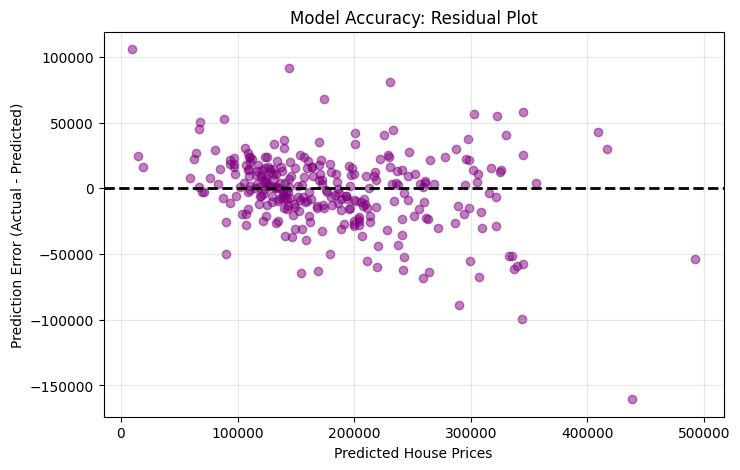

In [37]:
residuals = Y_test_final - preds_final

plt.figure(figsize=(8, 5))
plt.scatter(preds_final, residuals, alpha=0.5, color="purple")
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.title("Model Accuracy: Residual Plot")
plt.xlabel("Predicted House Prices")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.grid(True, alpha=0.3)
plt.show()

## Label Encoding with Linear Regression

The data is separated  into predictive features (X) by dropping the target column and isolating the target variable (Y) which represents the SalePrice of the houses. To handle the categorical text data in the columns, the code uses **pd.get_dummies(X, drop_first=True)**. This is the built-in pandas function that performs One-Hot Encoding. It automatically detects all your categorical columns and converts them into numeric columns filled with 1s and 0s.This process creates a brand-new binary column  for every unique category found across the categorical columns, dropping the first category to prevent redundant variables. Any remaining missing values are then replaced with zeros using .fillna(0)

The train_model function splits the newly expanded dataset into training and testing sets, 80% of the data to train and the remaining 20% for testing its accuracy. A **LinearRegression model** is initialized and fitted onto the training data to calculate the linear relationship between the encoded house characteristics and their respective prices. Once trained, the model generates price predictions for the unseen test houses.
 

In [38]:
X_label = df_train.drop(columns=["SalePrice"]).copy()
Y_label = df_train["SalePrice"]

label_encoders = {}
categorical_cols_label = X_label.select_dtypes(include="object").columns

for col in categorical_cols_label:
    le = LabelEncoder()
    X_label[col] = le.fit_transform(X_label[col].astype(str))
    label_encoders[col] = le

model_label, X_test_label, Y_test_label, preds_label = train_model(X_label, Y_label)

Mean Absolute Error: 19875.55
R2 Score: 0.8722


## Feature Hashing with Linear Regression
The target variable *(SalePrice)* is separated from the predictive features. Because **feature hashing** requires text to compute hash values, all the input features in the dataframe are converted into strings using .astype(str).values. This prepares both the categorical and numerical columns to be processed uniformly by the hasher.

FeatureHasher is initialized with n_features=20. This step takes all 24 columns of data and uses a hashing function to map every single unique value into one of 20 fixed numerical columns. This turns the complex categorical information into a compact, fixed-size numerical matrix, which prevents the dataset from bloating in size the way traditional one-hot encoding would.

linear_model function splits this processed data into training and testing sets, 80% for training the model and 20% for testing its performance. A **LinearRegression** model is trained on the hashed features to find the relationship between the hashed columns and the  target price. Once trained, the model predicts house prices on the unseen test set, yielding a Mean Absolute Error and an r2 Score.

In [39]:
from sklearn.feature_extraction import FeatureHasher
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

def train_model(X_data, Y_data):
    X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, Y_train)

    predictions = model.predict(X_test)
    mae = mean_absolute_error(Y_test, predictions)
    r2 = r2_score(Y_test, predictions)

    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")
    return model, X_test, Y_test, predictions

X_hash_source = df_train.drop(columns=["SalePrice"]).copy()
Y_hash = df_train["SalePrice"]

X_hash_str = X_hash_source.astype(str).values

hasher = FeatureHasher(n_features=20, input_type="string")
X_hashed = hasher.transform(X_hash_str)

model_hash, X_test_hash, Y_test_hash, preds_hash = train_model(X_hashed, Y_hash)

Mean Absolute Error: 38703.92
R2 Score: 0.4875


## Target Encoding
The dataset is separated into predictive features (X) by dropping the SalePrice column, while isolating the target variable (Y). The code automatically scans the set to group columns into either categorical types or numerical types. The dataset is split into training and testing. This early split is essential to prevent target leakage, ensuring that information from the test set does not accidentally spill into the encoding process.

A **TargetEncoder** is initialized and applied to the categorical columns. This  calculates the average SalePrice for each distinct category within the training data and replaces the text labels with those exact average dollar values. For example, if houses in a specific neighborhood sell for an average of $300,000, that neighborhood's text label is replaced by 300000.0. Once the categorical columns are converted into these representative averages, they are concatenated back together with the untouched numerical columns to form a complete, fully numeric feature set.

A **LinearRegression** model is initialized and fitted onto this target-encoded training matrix. Because the text columns have been directly transformed into target-correlated dollar amounts, the linear model can identify and learn structural pricing trends. The trained model then outputs house price predictions for the unseen test set, which are evaluated using Mean Absolute Error and the r2 Score to measure exactly how close the predictions are to the actual sale prices.


In [40]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder

X_target_source = df_train.drop(columns=["SalePrice"]).copy()
Y_target = df_train["SalePrice"]

categorical_cols_t = X_target_source.select_dtypes(include=["object", "category"]).columns
numerical_cols_t = X_target_source.select_dtypes(exclude=["object", "category"]).columns

X_train_t, X_test_t, Y_train_t, Y_test_t = train_test_split(
    X_target_source, Y_target, test_size=0.2, random_state=42
)

target_encoder = TargetEncoder(target_type="continuous", smooth="auto", random_state=42)
target_encoder.set_output(transform="pandas")

X_train_cat_encoded = target_encoder.fit_transform(X_train_t[categorical_cols_t], Y_train_t)
X_test_cat_encoded = target_encoder.transform(X_test_t[categorical_cols_t])

X_train_target_final = pd.concat(
    [X_train_cat_encoded, X_train_t[numerical_cols_t]], axis=1
).fillna(0)
X_test_target_final = pd.concat(
    [X_test_cat_encoded, X_test_t[numerical_cols_t]], axis=1
).fillna(0)

model_target = LinearRegression()
model_target.fit(X_train_target_final, Y_train_t)

preds_target = model_target.predict(X_test_target_final)
print(f"Mean Absolute Error: {mean_absolute_error(Y_test_t, preds_target):.2f}")
print(f"R2 Score: {r2_score(Y_test_t, preds_target):.4f}")


Mean Absolute Error: 19861.35
R2 Score: 0.8688


## Conclusion

Matching the encoding technique to what each variable actually represents made a meaningful difference. Treating MSSubClass as numeric, or collapsing "no feature" and "missing data" into the same fill value, would have fed the model incorrect signal. 
By fixing the dtype issue, separating the two kinds of missing values, and using ordinal encoding specifically for the ranked quality variables with one-hot reserved for true nominal categories, the resulting feature more accurately reflects the real structure of the data.

